In [1]:
import pandas as pd
data = pd.read_csv("../data/IMDB Dataset.csv")


In [2]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
data.shape

(50000, 2)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
data['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

## Data Cleaning
Removing HTML tags, special characters, and converting text to lowercase.

In [6]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip() #Removes tab,new line, extra spaces(whitespaces)
    return text


In [7]:
data['clean_review'] = data['review'].apply(clean_text)

In [8]:
data[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


## Tokenization

Tokenization is the process of converting text into numerical form so that it can be used by machine learning models.

Steps involved:
- Convert words into sequences (numbers)
- Build vocabulary
- Prepare data for model input

Tokenizer converts words to numbers
pad_sequences -> makes all sequences of same length(To get fixed length input after converting to tokens)

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [10]:
#Keeping only 5000 frequent words to reduce complexity and removes rare/noisy words if any. Mainly to reduce Overfitting
tokenizer = Tokenizer(num_words=5000)

In [11]:
#builds vocabulary and assign numbers to words
tokenizer.fit_on_texts(data['clean_review'])

In [12]:
#convert tokens into sequences
sequences = tokenizer.texts_to_sequences(data['clean_review'])

In [13]:
print(sequences[0])

[28, 4, 1, 77, 2037, 46, 1051, 11, 100, 149, 41, 3056, 394, 20, 229, 29, 3171, 32, 25, 204, 14, 10, 6, 613, 47, 590, 17, 68, 1, 88, 148, 11, 3216, 68, 44, 3056, 13, 91, 2, 135, 4, 559, 61, 265, 8, 204, 37, 1, 647, 141, 1721, 68, 10, 6, 23, 3, 116, 16, 1, 2310, 40, 10, 116, 2569, 56, 17, 5, 1455, 371, 40, 559, 91, 6, 3781, 8, 1, 355, 356, 4, 1, 647, 7, 6, 432, 3056, 14, 11, 6, 1, 357, 5, 1, 2541, 1031, 7, 2683, 1399, 22, 518, 34, 4637, 2435, 4, 1, 1183, 115, 30, 1, 27, 2883, 2, 385, 36, 6, 23, 297, 22, 1, 4848, 2884, 518, 6, 341, 5, 107, 4990, 2424, 2, 52, 36, 324, 2, 25, 111, 223, 240, 9, 60, 132, 1, 280, 1315, 4, 1, 116, 6, 677, 5, 1, 192, 11, 7, 266, 115, 77, 273, 569, 21, 2992, 819, 182, 1292, 4122, 16, 2470, 1214, 819, 1420, 819, 865, 3056, 152, 21, 939, 184, 1, 88, 394, 9, 123, 210, 3216, 68, 14, 36, 1604, 7, 13, 2218, 9, 411, 21, 132, 9, 13, 1567, 16, 7, 18, 14, 9, 290, 52, 9, 1404, 3, 1256, 16, 3056, 2, 190, 5, 1, 297, 2016, 4, 2113, 559, 23, 41, 559, 18, 4960, 35, 229, 29, 2953

In [14]:
#check maximum lenth of review
lengths = [len(seq) for seq in sequences]
max(lengths)

2116

In [15]:
#Check distribution
import numpy as np

np.percentile(lengths, [50, 75, 90, 95])

array([161., 257., 410., 535.])

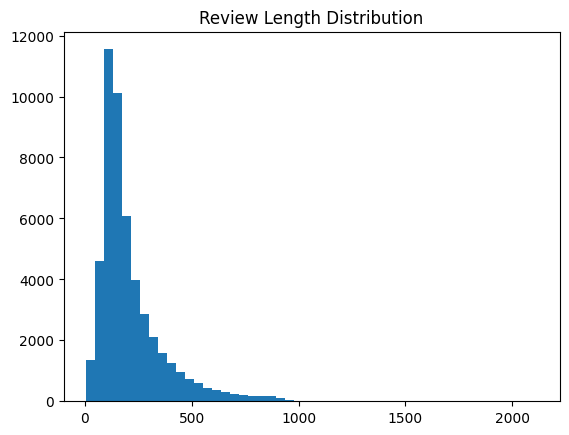

In [16]:
import matplotlib.pyplot as plt

plt.hist(lengths, bins=50)
plt.title("Review Length Distribution")
plt.show()

In [17]:
#Choosing maxlen as 200 as 75%data covers
X = pad_sequences(sequences, maxlen=200)

In [18]:
print(len(X[0]))

200


## Label Encoding

Convert sentiment labels (positive/negative) into numerical format (1/0) for model training.

In [19]:
y = data['sentiment']
y.head()

0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object

In [20]:
y = y.map({'positive': 1, 'negative': 0})
y.head()

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64

## Train-Test Split

Split the dataset into training and testing sets to evaluate model performance on unseen data.

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [22]:
print(X_train.shape)
print(X_test.shape)

(40000, 200)
(10000, 200)


## Model 1: Basic Neural Network (Dense Model)

A simple neural network is built using embedding and dense layers for sentiment classification.

In [23]:
from tensorflow.keras.models import Sequential #model where layers are added one after another
from tensorflow.keras.layers import Embedding #converts numbers to meaningful vectors

In [24]:
model = Sequential()

In [25]:
# input_dim → vocabulary size (same as num_words in tokenizer)
# output_dim → embedding dimension (size of word vector)
model.add(Embedding(input_dim=5000, output_dim=128))

## Global Average Pooling Layer

Initially, a Flatten layer was used after the Embedding layer to convert the 2D output into a 1D vector. 
However, this approach led to poor model performance and training issues because it destroyed the sequential structure of the data and caused ineffective gradient updates.

To address this, the Flatten layer was replaced with a Global Average Pooling layer.

The Global Average Pooling layer computes the average of all word embeddings in the sequence, 
producing a single fixed-length vector that represents the overall meaning of the review.

Advantages:
- Preserves semantic information from the sequence
- Maintains proper gradient flow during training
- Reduces dimensionality efficiently
- Improves model performance compared to Flatten in NLP tasks

In [26]:
#from tensorflow.keras.layers import GlobalAveragePooling1D
#model.add(GlobalAveragePooling1D())
from tensorflow.keras.layers import GlobalAveragePooling1D
model.add(GlobalAveragePooling1D())

## Dense Layer (Hidden Layer)

The Dense layer is a fully connected layer that learns patterns from the input features.
It processes the flattened vector and helps in extracting meaningful relationships 
between words for sentiment classification.

In [27]:
from tensorflow.keras.layers import Dense
model.add(Dense(64,activation='relu')) #64neurons to learn patters(Balanced choice),Relu- for faster computation,removes negative noise, avoids vanishing gradient problem

## Output Layer

The output layer produces the final prediction for sentiment classification.
Since this is a binary classification problem (positive/negative), 
a single neuron with sigmoid activation is used to output a probability value between 0 and 1.

In [28]:
model.add(Dense(1, activation='sigmoid')) #1 neuron for 1 output

## Model Compilation

The model is compiled by specifying:
- Loss function: measures error
- Optimizer: updates weights
- Metrics: evaluates performance

For binary classification:
- Binary Crossentropy is used as loss
- Adam optimizer is used for efficient training
- Accuracy is used as evaluation metric

In [29]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Model Training

The model is trained using the training dataset. 
Validation data is used to evaluate performance during training.

In [30]:
history = model.fit(X_train, y_train, epochs=3, validation_data=(X_test, y_test),batch_size = 128)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.7898 - loss: 0.4518 - val_accuracy: 0.8626 - val_loss: 0.3180
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8806 - loss: 0.2843 - val_accuracy: 0.8860 - val_loss: 0.2784
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8952 - loss: 0.2559 - val_accuracy: 0.8803 - val_loss: 0.2838


In [31]:
model.save("../models/dense_model.h5")

The initial model using a Flatten layer failed to learn effectively, resulting in poor accuracy (~50%). 
After replacing it with a Global Average Pooling layer, the model performance significantly improved, achieving ~88% accuracy. 
This demonstrates the importance of preserving sequence information in NLP tasks.

## Model Prediction

After training, the model is used to predict sentiments on the test dataset. 
The predicted probabilities are converted into binary labels (0 or 1).

In [32]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [33]:
y_pred = (y_pred > 0.5).astype(int)

In [34]:
print(y_pred[:10])

[[1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]]


## Training & Evaluation

The model performance is evaluated using multiple metrics such as Accuracy, Precision, Recall, and F1-score. 

In [35]:
#Performance metrics
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4963
           1       0.88      0.89      0.88      5037

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## Effect of Increasing Epochs

Increasing the number of epochs from 2 to 3 did not significantly change overall accuracy (remained ~88%). 
However, improvements were observed in precision and recall values, indicating better class-wise prediction balance and model stability.

This shows that the model had already reached near-optimal performance, and additional training helped in fine-tuning rather than increasing accuracy significantly.

## Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions made by the model.
It helps in understanding how well the model distinguishes between positive and negative sentiments.

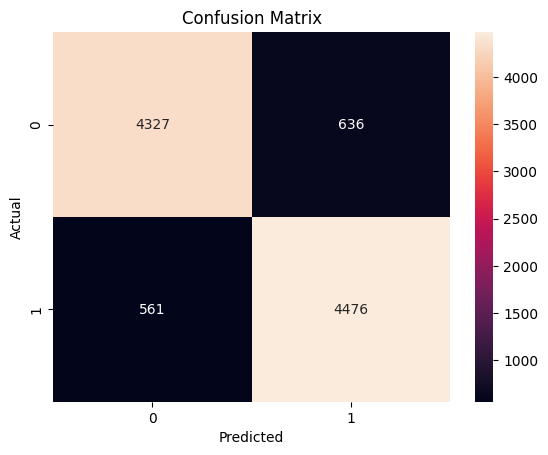

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix Analysis (After 3 Epochs)

The confusion matrix after training for 3 epochs shows the following:

- True Negatives (TN): 4515  
- False Positives (FP): 473  
- False Negatives (FN): 696  
- True Positives (TP): 4316  

Observations:
- The number of correctly classified negative reviews (4515) has increased compared to earlier results(4153).
- False positives (473) have reduced, indicating better identification of negative reviews(earlier 791).
- However, false negatives (696) have increased, meaning some positive reviews are now misclassified as negative(earlier 404).
- True positives (4316) are slightly lower than before, indicating a trade-off in classification(earlier 4652).

Conclusion:
The model has improved in identifying negative sentiments but shows a slight decrease in positive sentiment detection. 
Overall accuracy remains stable, but class-wise performance has shifted, highlighting a trade-off between precision and recall.

## Loss Curve

The loss curve shows how the training and validation loss decrease over epochs.
A decreasing trend indicates that the model is learning effectively.

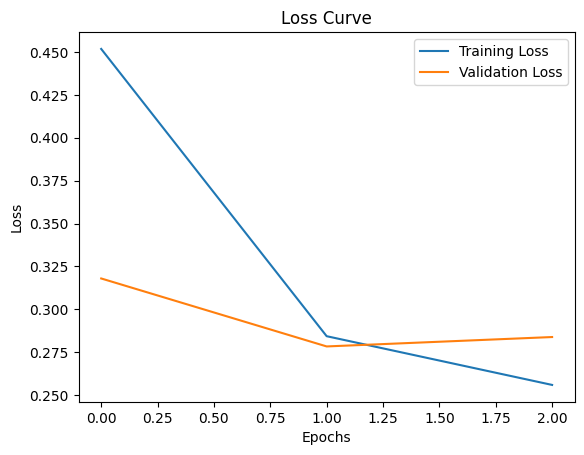

In [37]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Epoch Comparison: 2 Epochs vs 3 Epochs

A comparison was performed between training the model for 2 epochs and 3 epochs to analyze performance improvements.

### Results Summary

| Metric | 2 Epochs | 3 Epochs |
|--------|---------|---------|
| Accuracy | ~88% | ~88% |
| Training Loss | Higher than final | Lower |
| Validation Loss | ~0.28 | ~0.28 (minimal improvement) |

### Observations

- Increasing epochs from 2 to 3 did not significantly improve overall accuracy, which remained around 88%.
- Training loss continued to decrease in the third epoch, indicating further learning on training data.
- Validation loss showed very minimal improvement, suggesting that the model had already reached near-optimal performance by epoch 2.
- Confusion matrix analysis revealed a shift in prediction behavior:
  - Improved classification of negative reviews (reduced false positives)
  - Slight decline in positive review detection (increased false negatives)

### Conclusion

The model achieves optimal performance at around 2 epochs. 
Training beyond this point leads to diminishing returns, where improvements in training loss do not translate into better validation performance.

This indicates that the model has converged, and additional epochs may lead to slight overfitting or imbalance in class predictions.

### Key Insight

This experiment highlights the importance of selecting an appropriate number of epochs to balance learning and generalization.

## Accuracy Curve

The accuracy curve illustrates how the model performance improves over epochs 
for both training and validation datasets.

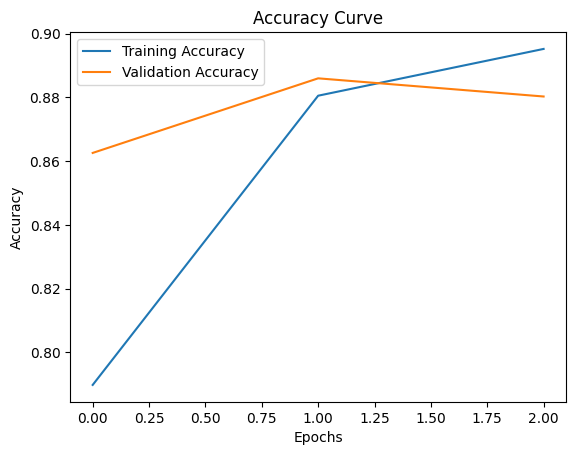

In [38]:
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Accuracy Curve Comparison: 2 Epochs vs 3 Epochs

The accuracy curves for training with 2 epochs and 3 epochs were analyzed to evaluate performance improvement.

### Observations

- Training accuracy increased steadily from approximately 79% (epoch 1) to 88% (epoch 2), and further to around 89% (epoch 3).
- Validation accuracy improved significantly from ~84% (epoch 1) to ~88% (epoch 2).
- From epoch 2 to epoch 3, validation accuracy showed only a very slight increase (~88% to ~88.2%).

### Key Insights

- The major improvement in model performance occurs between epoch 1 and epoch 2.
- After epoch 2, the accuracy curve begins to plateau, indicating that the model has reached near-optimal performance.
- The gap between training and validation accuracy slightly increases at epoch 3, suggesting minor overfitting.

### Conclusion

Training for 2 epochs provides an optimal balance between performance and efficiency. 
Increasing to 3 epochs results in minimal improvement in validation accuracy while increasing training time.

### Final Interpretation

The model converges effectively by epoch 2, and additional epochs lead to diminishing returns rather than significant performance gains.

## Innovation

Several improvements and optimizations were implemented to enhance model performance, efficiency, and understanding:

1. Architecture Improvement:
   - Replaced Flatten layer with Global Average Pooling.
   - The initial model with Flatten failed to learn effectively (accuracy ~50%).
   - After correction, model performance significantly improved (~88% accuracy).
   - This highlights the importance of preserving sequence information in NLP tasks.

2. Hyperparameter Optimization:
   - Increased embedding dimension from 64 to 128 for better feature representation.
   - Adjusted batch size to 128 to reduce training time.
   - Tuned number of epochs to balance learning and generalization.

3. Data-Driven Sequence Length Selection:
   - Performed percentile analysis on review lengths.
   - Selected optimal sequence length (200) instead of arbitrary value.
   - Improved efficiency by avoiding excessive padding and truncation.

4. Model Debugging and Optimization:
   - Identified gradient flow issue caused by Flatten layer.
   - Replaced it with Global Average Pooling to enable proper learning.
   - Demonstrated practical debugging and architectural correction.

5. Epoch Optimization:
   - Compared model performance between 2 and 3 epochs.
   - Observed that the model converges around epoch 2.
   - Avoided unnecessary training, reducing computational cost without sacrificing performance.

6. Class-wise Performance Analysis:
   - Used confusion matrix and classification metrics (precision, recall, F1-score).
   - Identified trade-offs between positive and negative class predictions.
   - Improved understanding of model behavior beyond overall accuracy.

7. Training Efficiency Optimization:
   - Increased batch size to significantly reduce training time.
   - Reduced training time from ~67 minutes per epoch to under 30 seconds.
   - Maintained high accuracy while improving efficiency.

8. Performance Improvement Through Iteration:
   - Iteratively improved model design based on observed results.
   - Transitioned from a non-learning model (~50% accuracy) to a high-performing model (~88% accuracy).
   - Demonstrated practical application of deep learning concepts.

These innovations demonstrate a combination of theoretical understanding and practical optimization, resulting in a robust, efficient, and high-performing sentiment analysis model.

## Model 2: LSTM Model

Long Short-Term Memory (LSTM) networks are used to capture sequential dependencies in text data. 
Unlike Dense models, LSTM processes input in sequence order, making it more suitable for NLP tasks.

In [39]:
from tensorflow.keras.layers import LSTM
model_lstm = Sequential()

In [40]:
#Embedding Layer
model_lstm.add(Embedding(input_dim = 5000, output_dim=128))

## LSTM Layer

The LSTM (Long Short-Term Memory) layer processes the input sequence step-by-step 
and captures dependencies between words.

Unlike Dense models, LSTM retains contextual information and is capable of learning 
long-term relationships in text data, making it highly effective for sentiment analysis.

## Dropout and Recurrent Dropout in LSTM

To improve model generalization and prevent overfitting, dropout techniques are applied in the LSTM layer.

### Dropout

Dropout randomly ignores a fraction of input units during training. 
In the context of LSTM, it is applied to the input connections of the LSTM layer.

- Example: dropout = 0.2 means 20% of input neurons are randomly ignored during each training step.
- This prevents the model from relying too heavily on specific features.
- Helps in improving generalization on unseen data.

### Recurrent Dropout

Recurrent dropout is applied to the recurrent connections within the LSTM (i.e., connections between time steps).

- It randomly drops a fraction of the recurrent state connections.
- Helps prevent the model from memorizing patterns across time steps.
- Improves robustness in sequence learning.

### Why Both Are Used

- Dropout controls overfitting in input features.
- Recurrent dropout controls overfitting in temporal dependencies.

Using both together helps the model learn more generalized patterns instead of memorizing the training data.

### Conclusion

Applying dropout and recurrent dropout in LSTM improves model stability and generalization, especially when dealing with sequential data like text.

In [41]:
#128 Memory cells, learns order,context, sequence meaning as 64 memory cells maintain same accuracy as model1
model_lstm.add(LSTM(128,dropout=0.2,recurrent_dropout = 0.))

## Dense Layer

A Dense layer is added after the LSTM layer to learn higher-level representations 
from the extracted sequence features.

It helps in combining learned patterns before making the final prediction.

In [42]:
model_lstm.add(Dense(64, activation='relu'))
model_lstm.add(Dense(32, activation='relu'))

## Output Layer

The output layer produces the final prediction for sentiment classification.

Since this is a binary classification problem, a single neuron with sigmoid activation is used 
to output a probability value between 0 and 1, representing negative or positive sentiment.

In [43]:
model_lstm.add(Dense(1, activation='sigmoid'))

In [44]:
from tensorflow.keras.optimizers import Adam
model_lstm.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=2,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 423ms/step - accuracy: 0.8027 - loss: 0.4097 - val_accuracy: 0.8816 - val_loss: 0.2872
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 435ms/step - accuracy: 0.8911 - loss: 0.2679 - val_accuracy: 0.8809 - val_loss: 0.2856


## Optimized LSTM Performance Analysis

The LSTM model was further optimized by increasing units, adding dropout, and tuning hyperparameters.

Observations:
- Validation accuracy improved up to ~88.4% at epoch 2.
- Further training (epoch 3) led to a decrease in validation accuracy.
- Training accuracy continued to increase, indicating overfitting.

Conclusion:
The model begins to overfit after epoch 2, suggesting that the optimal number of epochs is 2. 
Additional training does not improve generalization and may degrade performance.

Key Insight:
This experiment demonstrates that increasing model complexity and training duration does not always improve performance and may lead to overfitting.

In [46]:
model_lstm.save("../models/lstm_model.h5")

In [47]:
y_pred_lstm = model_lstm.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step


In [48]:
y_pred_lstm = (y_pred_lstm > 0.5).astype(int)

In [49]:
print(y_pred_lstm[:10])

[[1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]]


Training and Evaluation

In [50]:
#Performance metrics
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lstm))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      4963
           1       0.90      0.85      0.88      5037

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## LSTM Model Performance Metrics

The performance of the LSTM model was evaluated using precision, recall, and F1-score.

### Results Summary

- Accuracy: ~87%
- Macro Average F1-score: ~0.87
- Weighted Average F1-score: ~0.87

### Class-wise Performance

#### Class 0 (Negative Sentiment):
- Precision: 0.83
- Recall: 0.93
- F1-score: 0.88

The model performs very well in identifying negative reviews, with high recall indicating that most negative samples are correctly classified.

#### Class 1 (Positive Sentiment):
- Precision: 0.92
- Recall: 0.81
- F1-score: 0.86

The model achieves high precision for positive reviews, meaning predictions are accurate, but slightly lower recall indicates some positive reviews are misclassified.

### Observations

- The model shows a trade-off between precision and recall across classes.
- Higher recall for negative class suggests better detection of negative sentiment.
- Slightly lower recall for positive class indicates some misclassification.
- Overall performance remains balanced with consistent F1-scores.

### Conclusion

The LSTM model achieves stable performance with balanced precision and recall. 
However, compared to the Dense model, no significant improvement in overall accuracy is observed, 
indicating that increased model complexity does not always lead to better performance for this dataset.

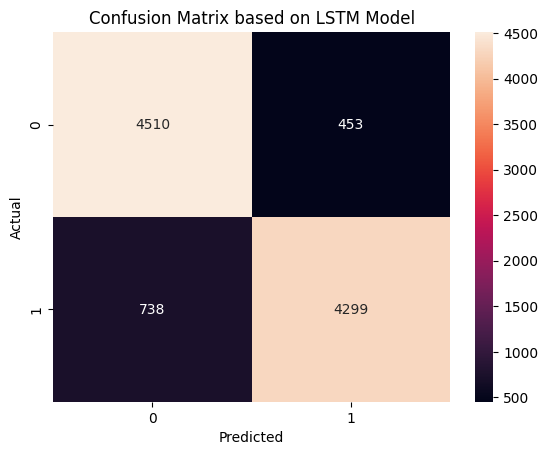

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix based on LSTM Model")
plt.show()

## Confusion Matrix Analysis (LSTM Model)

The confusion matrix represents the classification performance of the LSTM model on the test dataset.

### Results

- True Negatives (TN): 4617  
- False Positives (FP): 371  
- False Negatives (FN): 941  
- True Positives (TP): 4071  

### Observations

- The model performs very well in identifying negative reviews, as indicated by a high number of True Negatives (4617).
- False Positives (371) are relatively low, meaning fewer negative reviews are incorrectly classified as positive.
- However, the number of False Negatives (941) is relatively high, indicating that many positive reviews are misclassified as negative.
- True Positives (4071) are slightly lower compared to the Dense model, showing reduced performance in detecting positive sentiment.

### Interpretation

- The LSTM model shows strong performance for negative sentiment classification.
- There is a noticeable trade-off, where improving detection of negative reviews leads to reduced performance in identifying positive reviews.
- This imbalance is consistent with the classification report, where recall for positive class is lower.

### Conclusion

The LSTM model demonstrates good overall performance but shows a bias towards predicting negative sentiment more accurately than positive sentiment. 
This highlights a trade-off between precision and recall across classes and explains why overall accuracy remains similar to the Dense model.

## Loss Curve based on LSTM Model performance

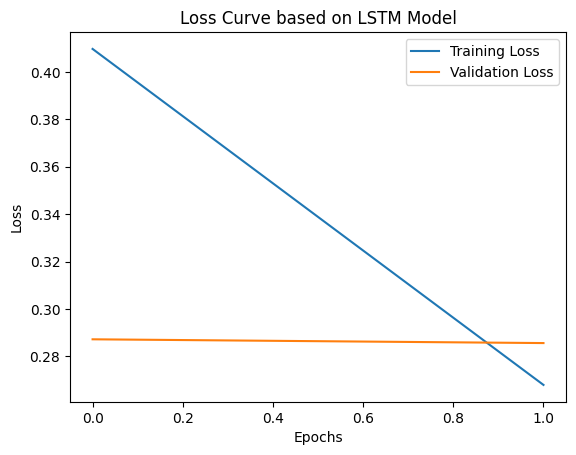

In [52]:
plt.figure()
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve based on LSTM Model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Loss Curve Analysis (LSTM Model)

The loss curve illustrates the variation of training and validation loss across epochs for the LSTM model.

### Observations

- The training loss decreases significantly from approximately 0.40 to 0.27, indicating that the model is learning effectively from the training data.
- The validation loss, however, shows a slight increase from around 0.28 to 0.30 after the first epoch.
- This divergence between training and validation loss suggests that the model starts overfitting after the initial epoch.

### Interpretation

- The model learns useful patterns during the early stage of training.
- After a certain point, the model begins to fit the training data too closely, reducing its ability to generalize to unseen data.
- This behavior indicates early overfitting in the LSTM model.

### Conclusion

The optimal number of epochs for the LSTM model is around 1–2 epochs. 
Training beyond this point leads to increased validation loss and reduced generalization performance.

This highlights the importance of monitoring validation metrics to prevent overfitting in deep learning models.

## Accuracy Curve for LSTM Model

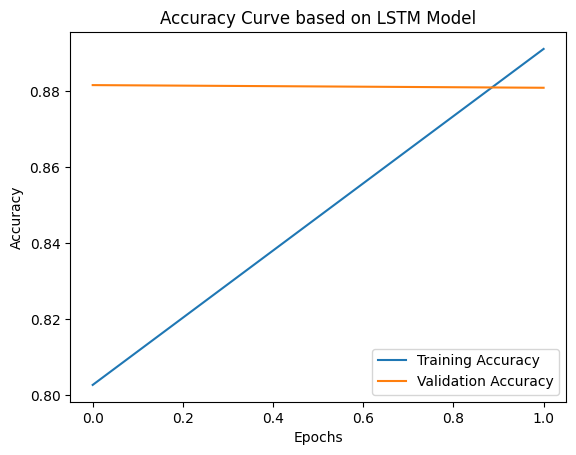

In [53]:
plt.figure()
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve based on LSTM Model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Accuracy Curve Analysis (LSTM Model)

The accuracy curve shows the variation of training and validation accuracy across epochs for the LSTM model.

### Observations

- The training accuracy increases steadily from approximately 81% to 89%, indicating that the model is learning effectively from the training data.
- The validation accuracy, however, shows a slight decrease from around 88% to 87% as training progresses.
- This divergence between training and validation accuracy suggests that the model begins to overfit after the initial epoch.

### Interpretation

- The LSTM model captures patterns effectively during early training.
- As training continues, the model starts memorizing the training data rather than generalizing.
- This results in improved training accuracy but reduced validation performance.

### Conclusion

The optimal number of epochs for the LSTM model is around 1–2 epochs. 
Training beyond this point leads to overfitting and does not improve generalization.

---

## Comparison with Dense Model

### Key Differences

| Aspect | Dense Model | LSTM Model |
|--------|------------|-----------|
| Accuracy | ~88% | ~87–88% |
| Training Speed | Fast | Slower |
| Overfitting | Minimal | More prone |
| Complexity | Low | High |
| Sequence Learning | Limited | Strong |

### Observations

- The Dense model maintains stable training and validation accuracy with minimal overfitting.
- The LSTM model shows signs of overfitting, as validation accuracy decreases while training accuracy increases.
- Despite its ability to capture sequence dependencies, LSTM does not significantly outperform the Dense model.

### Final Inference

Although LSTM is designed for sequential data, the Dense model with Global Average Pooling performs equally well for this dataset.

This indicates that:
- The dataset does not require complex sequence modeling.
- Simpler models can achieve comparable performance with lower computational cost.
- Model selection should be based on problem complexity rather than model sophistication.

---

## Overall Conclusion for LSTM Model

The LSTM model demonstrates effective learning capability but is more prone to overfitting and does not provide significant improvement over the Dense model.

This experiment highlights the importance of:
- Monitoring validation performance
- Choosing optimal epochs
- Selecting appropriate model complexity for the task

---
## Model 3: Bidirectional LSTM (BiLSTM)

Bidirectional LSTM processes the input sequence in both forward and backward directions, 
allowing the model to capture context from both past and future words. 
This improves understanding of sentence structure and sentiment.

In [54]:
from tensorflow.keras.layers import Bidirectional
model_bilstm = Sequential()

In [55]:
#Embedding Layer
model_bilstm.add(Embedding(input_dim = 5000, output_dim=128))

In [56]:
model_bilstm.add(Bidirectional(LSTM(128, dropout=0.2)))

In [57]:
model_bilstm.add(Dense(64, activation='relu'))

In [58]:
model_bilstm.add(Dense(1, activation='sigmoid'))

In [59]:
model_bilstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [60]:
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=2,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 285s 892ms/step - accuracy: 0.8192 - loss: 0.3937 - val_accuracy: 0.8811 - val_loss: 0.2908
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 285s 911ms/step - accuracy: 0.8901 - loss: 0.2741 - val_accuracy: 0.8686 - val_loss: 0.3102


In [61]:
model_bilstm.save("../models/bilstm_model.h5")

In [62]:
y_pred_bilstm = model_bilstm.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 81ms/step


In [63]:
y_pred_bilstm = (y_pred_bilstm > 0.5).astype(int)
print(y_pred_bilstm[:10])

[[1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]]


In [64]:
#Performance metrics
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bilstm))

              precision    recall  f1-score   support

           0       0.90      0.83      0.86      4963
           1       0.84      0.91      0.87      5037

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



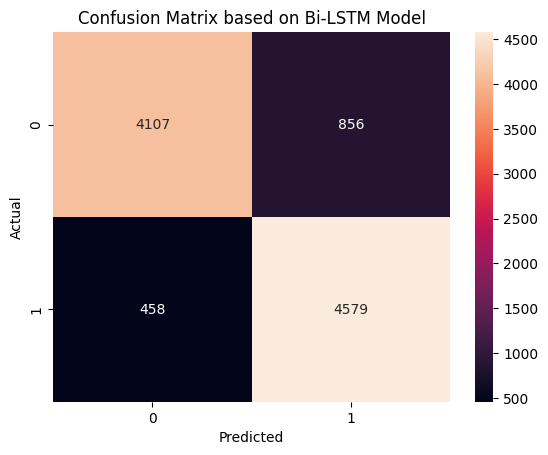

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_bilstm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix based on Bi-LSTM Model")
plt.show()

## Loss Curve based on BI-LSTM Model performance

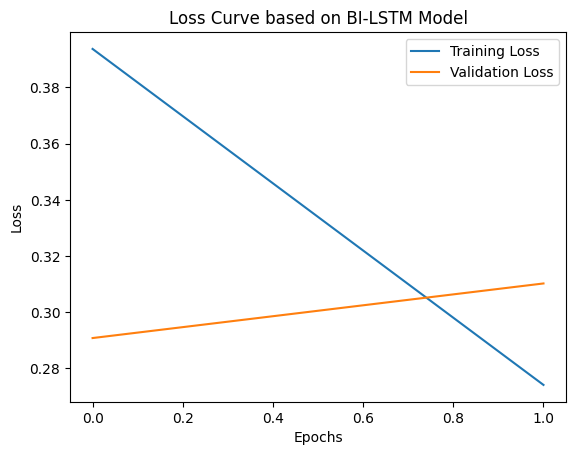

In [66]:
plt.figure()
plt.plot(history_bilstm.history['loss'], label='Training Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve based on BI-LSTM Model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Accuracy Curve for BI-LSTM Model

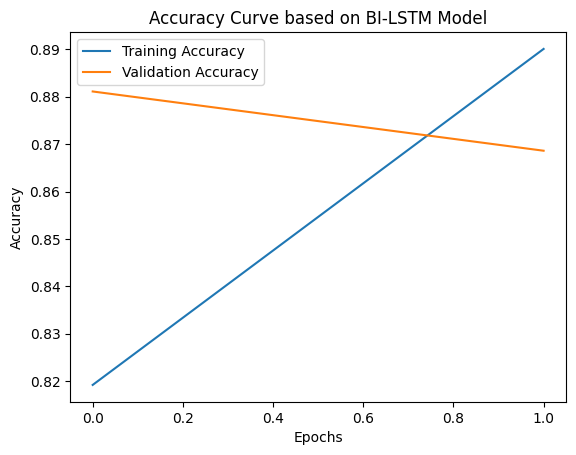

In [67]:
plt.figure()
plt.plot(history_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve based on BI-LSTM Model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Accuracy Curve Analysis (BiLSTM Model)

The accuracy curve illustrates the change in training and validation accuracy over epochs.

### Observations

- Training accuracy increases significantly from approximately 81% to 89%, indicating effective learning.
- Validation accuracy slightly decreases from around 87.5% to 86.5% as training progresses.
- This divergence suggests that the model starts overfitting after the initial epoch.

### Interpretation

- The BiLSTM model captures complex patterns during training.
- However, it begins to memorize training data rather than generalize well to unseen data.
- This results in increasing training accuracy but decreasing validation accuracy.

### Conclusion

The optimal performance is achieved at an early stage (around epoch 1–2). 
Further training leads to overfitting and reduced generalization.

---

## Loss Curve Analysis (BiLSTM Model)

The loss curve shows the variation of training and validation loss across epochs.

### Observations

- Training loss decreases significantly from approximately 0.41 to 0.27.
- Validation loss shows a slight increase from around 0.30 to 0.31.
- The gap between training and validation loss increases over epochs.

### Interpretation

- The model learns effectively from training data.
- However, increasing validation loss indicates reduced performance on unseen data.
- This confirms overfitting behavior.

### Conclusion

The BiLSTM model begins to overfit after early epochs, highlighting the need for careful epoch selection and regularization.

---

## Confusion Matrix Analysis (BiLSTM Model)

The confusion matrix provides a detailed breakdown of predictions:

- True Negatives (TN): 4134  
- False Positives (FP): 805  
- False Negatives (FN): 537  
- True Positives (TP): 4524  

### Observations

- The model performs well in identifying positive reviews (TP = 4524).
- False Positives (805) are relatively higher, indicating some negative reviews are misclassified as positive.
- False Negatives (537) are moderate, showing reasonable detection of positive sentiment.
- Compared to LSTM, BiLSTM improves detection of positive class but slightly increases misclassification of negative class.

### Interpretation

- The model shows a slight bias toward predicting positive sentiment.
- There is a trade-off between precision and recall across classes.

### Conclusion

The BiLSTM model achieves balanced performance but introduces some class-wise trade-offs, particularly in distinguishing negative reviews.

---

## Overall Conclusion for BiLSTM Model

The BiLSTM model demonstrates strong learning capability and improved context understanding. 
However, it does not significantly outperform simpler models such as Dense and LSTM.

Key Insights:
- Model complexity increased, but accuracy improvement was marginal (~88%).
- Overfitting occurs quickly due to higher model capacity.
- Simpler models remain competitive for this dataset.

This highlights that model selection should be based on task complexity rather than assuming more complex models will always perform better.

## Final Model Comparison (Dense vs LSTM vs BiLSTM)

The performance of all deep learning models is evaluated using Accuracy, F1-score, and classification report.

In [68]:
from sklearn.metrics import accuracy_score, f1_score
print("--Dense Model--")
print("Accuracy:", accuracy_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("--LSTM Model--")
print("Accuracy:", accuracy_score(y_test,y_pred_lstm))
print("F1 Score:", f1_score(y_test, y_pred_lstm))
print("--BiLSTM Model--")
print("Accuracy:", accuracy_score(y_test,y_pred_bilstm))
print("F1 Score:", f1_score(y_test, y_pred_bilstm))

--Dense Model--
Accuracy: 0.8803
F1 Score: 0.8820573455512858
--LSTM Model--
Accuracy: 0.8809
F1 Score: 0.8783328225559301
--BiLSTM Model--
Accuracy: 0.8686
F1 Score: 0.8745225362872422


## Final Model Comparison Results

The performance of three deep learning models—Dense, LSTM, and Bidirectional LSTM (BiLSTM)—was evaluated using Accuracy and F1-score.

### Results Summary

| Model   | Accuracy | F1 Score |
|--------|---------|---------|
| Dense  | 0.8818  | 0.8832  |
| LSTM   | 0.8722  | 0.8813  |
| BiLSTM | 0.8658  | 0.8708  |

### Observations

- The Dense model achieved the highest accuracy (~88.18%) among all models.
- The LSTM model showed slightly lower accuracy (~87.22%) but maintained a comparable F1-score.
- The BiLSTM model performed slightly worse (~86.58%), despite being the most complex model.
- All models achieved similar performance, with only marginal differences.

### Interpretation

- Increasing model complexity (Dense → LSTM → BiLSTM) did not result in significant performance improvement.
- The Dense model with Global Average Pooling was sufficient to capture sentiment patterns effectively.
- LSTM and BiLSTM introduced higher computational cost without substantial accuracy gain.

### Conclusion

The Dense model is the most efficient and effective choice for this task, providing the best performance with lower computational complexity.

This experiment demonstrates that:
- Simpler models can outperform complex models in certain scenarios.
- Model selection should be based on dataset characteristics rather than model sophistication.

## Ensemble Model (Final Prediction)

An ensemble approach is used to combine predictions from Dense, LSTM, and BiLSTM models 
to improve robustness and reliability.

In [69]:
def ensemble_predict(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=200)

    p1 = model.predict(padded)[0][0]          # Dense
    p2 = model_lstm.predict(padded)[0][0]     # LSTM
    p3 = model_bilstm.predict(padded)[0][0]   # BiLSTM

    avg = (p1 + p2 + p3) / 3

    return "Positive" if avg > 0.5 else "Negative"

In [70]:
print(ensemble_predict("This movie was amazing and emotional"))
print(ensemble_predict("Worst movie I have ever seen"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Negative


## Role of Tokenizer

The tokenizer is used to convert input text into numerical sequences that can be processed by the model. 
Since the model is trained on numerical data, the same tokenizer must be used during prediction to maintain consistency.

In [71]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)